# Using GLT to analyse basic gurobi logs on tests and to final instances 

## Libs

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import gurobi_logtools as glt 
import glob
import seaborn as sns
import re



## Data

In [2]:
log_files = glob.glob("logs/*.log", recursive=True)
results = glt.parse(log_files)
summary = results.summary()
nodelog_progress = results.progress("nodelog")


In [3]:
summary['blocks'] = summary['LogFilePath'].str.extract(r'(\d+)B').astype(float)
summary['fronts'] = summary['LogFilePath'].str.extract(r'(\d+)F').astype(float)
summary['gamma']  = summary['LogFilePath'].str.extract(r'gamma_(\d+d\d+)')[0].str.replace('d', '.').astype(float)
summary['theta']  = summary['LogFilePath'].str.extract(r'theta(\d+d\d+)')[0].str.replace('d', '.').astype(float)

summary.head(5)

,Platform,Time,PhysicalCores,LogicalProcessors,Threads,NumConstrs,NumVars,NumNZs,Fingerprint,PresolvedNumConVars,...,PushPhaseDInf,PushPhaseEndTime,Cuts: Inf proof,LogFile (Parameter),Seed,Version,blocks,fronts,gamma,theta
0,linux64,2026-03-12 14:41:18,4,8,8,72721,1531121,4650214,0x0bfe3080,8195,...,NaN,NaN,NaN,"""logs/log_gurobi_100B_20260312144011.log""",0,13.0.1,100.0,3.0,0.25,0.1
1,linux64,2026-03-13 10:37:00,4,8,8,72721,1531121,4650214,0xeee82e29,8195,...,NaN,NaN,NaN,"""logs/100B_3FRobust_gamma_0d25_theta0d2.log""",0,13.0.1,100.0,3.0,0.25,0.2
2,linux64,2026-03-13 14:34:33,4,8,8,72721,1531121,4650214,0xd2c48ab8,8195,...,NaN,NaN,NaN,"""logs/100B_3FRobust_gamma_0d25_theta0d3.log""",0,13.0.1,100.0,3.0,0.25,0.3
3,linux64,2026-03-12 16:10:04,4,8,8,72721,1531121,4650214,0xc7f5b047,8195,...,NaN,NaN,NaN,"""logs/100B_3FRobust_gamma_0d5_theta0d1.log""",0,13.0.1,100.0,3.0,0.50,0.1
4,linux64,2026-03-13 11:41:07,4,8,8,72721,1531121,4650214,0x85b16ec1,8195,...,NaN,NaN,NaN,"""logs/100B_3FRobust_gamma_0d5_theta0d2.log""",0,13.0.1,100.0,3.0,0.50,0.2


## Plots

#### Solution data 

In [4]:
summary.columns

Index(['Platform', 'Time', 'PhysicalCores', 'LogicalProcessors', 'Threads',
       'NumConstrs', 'NumVars', 'NumNZs', 'Fingerprint', 'PresolvedNumConVars',
       'PresolvedNumIntVars', 'PresolvedNumBinVars', 'MinCoeff', 'MaxCoeff',
       'MinObjCoeff', 'MaxObjCoeff', 'MinBound', 'MaxBound', 'MinRHS',
       'MaxRHS', 'PresolveTime', 'PresolvedNumConstrs', 'PresolvedNumVars',
       'PresolvedNumNZs', 'RelaxObj', 'RelaxIterCount', 'RelaxTime',
       'PreTreeSolutions', 'NodeCount', 'IterCount', 'Runtime', 'Work',
       'ObjVal', 'ObjBound', 'MIPGap', 'Cuts: Gomory', 'Cuts: Cover',
       'Cuts: Implied bound', 'Cuts: Projected implied bound', 'Cuts: MIR',
       'Cuts: Flow cover', 'Cuts: Zero half', 'Cuts: RLT',
       'Cuts: Relax-and-lift', 'Cores', 'SolCount', 'Status', 'ModelType',
       'ChangedParams', 'LogFilePath', 'LogNumber', 'Cuts: Lift-and-project',
       'Cuts: Mixing', 'Cuts: GUB cover', 'OrderingTime', 'BarIterCount',
       'Cuts: Mod-K', 'PushPhasePInf', 'PushPha

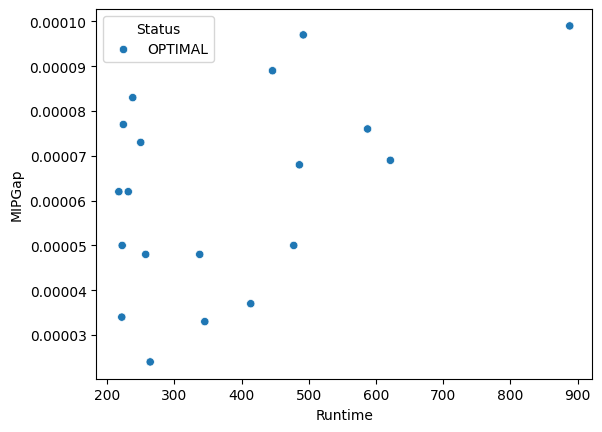

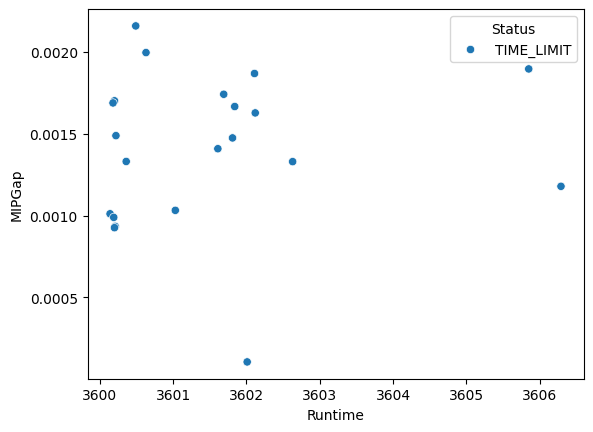

In [5]:
sns.scatterplot(summary[summary['Runtime'] < 1000],x='Runtime',y='MIPGap',hue = 'Status',palette='tab10')
plt.show()

sns.scatterplot(summary[summary['Runtime'] > 1000],x='Runtime',y='MIPGap', hue = 'Status',palette='tab10')
plt.show()

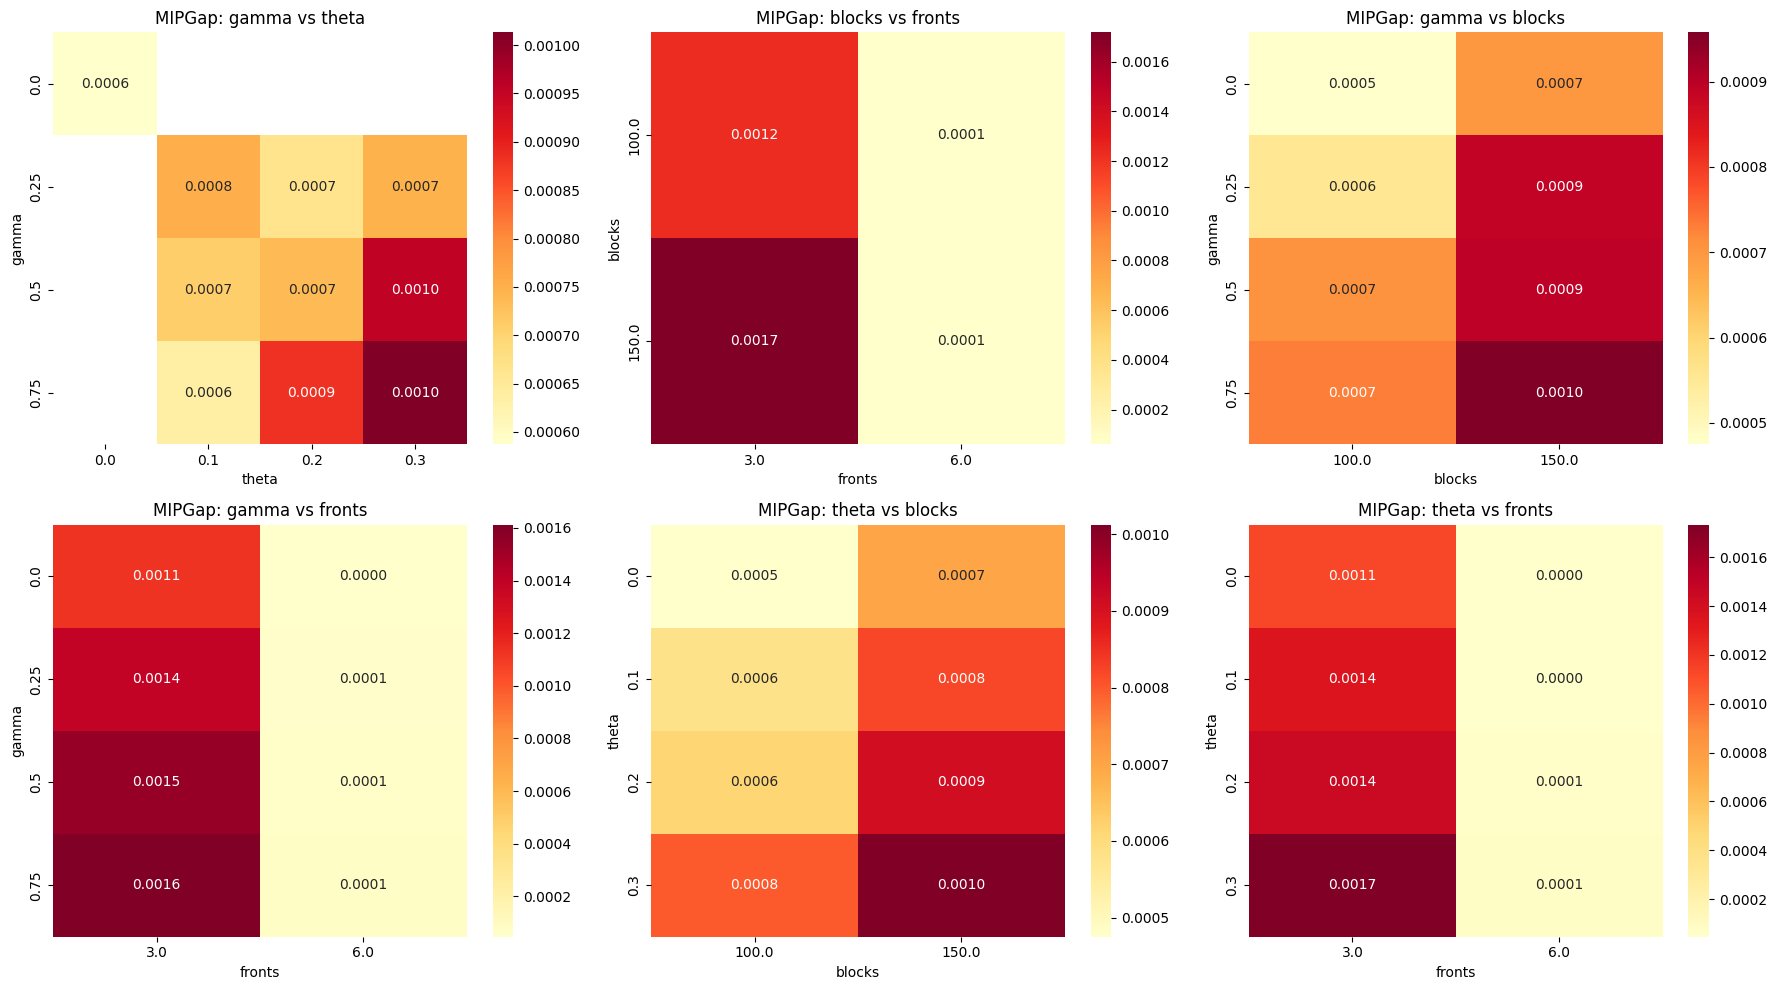

In [6]:
heatmaps = [
    ('gamma', 'theta'),
    ('blocks', 'fronts'),
    ('gamma', 'blocks'),
    ('gamma', 'fronts'),
    ('theta', 'blocks'),
    ('theta', 'fronts'),]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (row, col) in zip(axes.flatten(), heatmaps):
    pivot = summary.pivot_table(values='MIPGap', index=row, columns=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'MIPGap: {row} vs {col}')

plt.tight_layout()
plt.show()

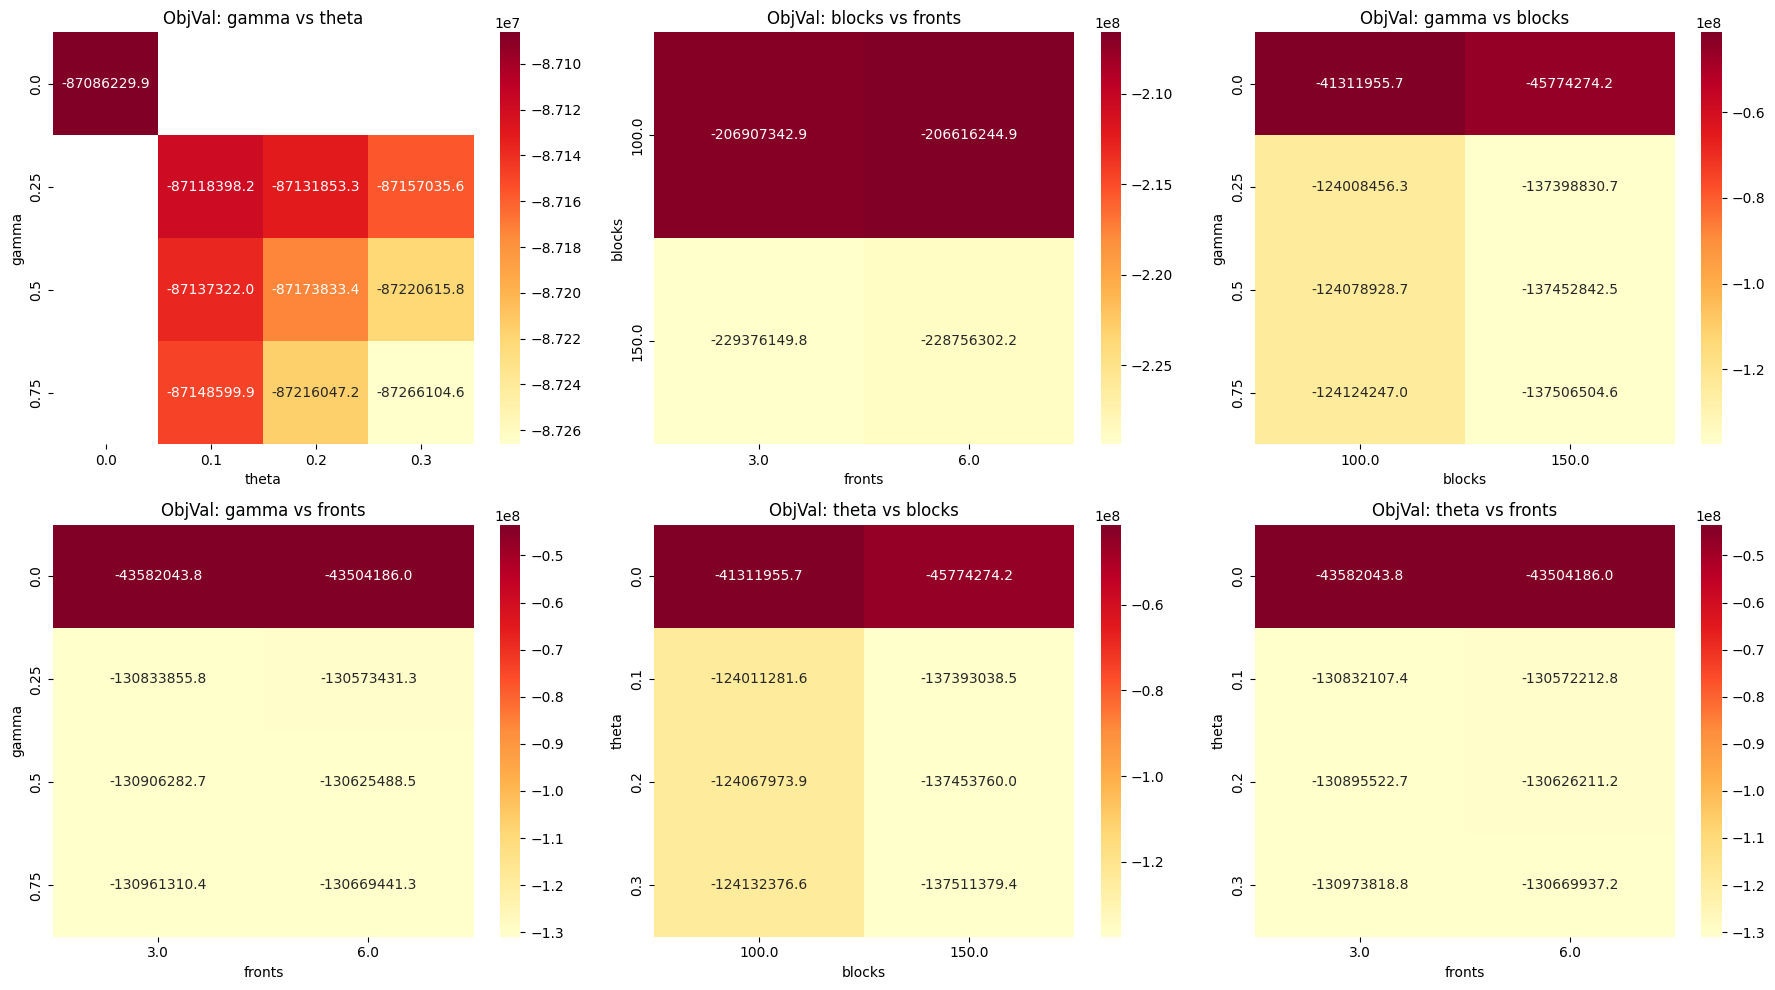

In [24]:
heatmaps = [
    ('gamma', 'theta'),
    ('blocks', 'fronts'),
    ('gamma', 'blocks'),
    ('gamma', 'fronts'),
    ('theta', 'blocks'),
    ('theta', 'fronts'),
]

summary['ObjVal'] = - summary['ObjVal']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (row, col) in zip(axes.flatten(), heatmaps):
    pivot = summary.pivot_table(values='ObjVal', index=row, columns=col, aggfunc='sum')
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'ObjVal: {row} vs {col}')

plt.tight_layout()
plt.show()

In [ ]:
s

2071.36825